In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from IPython.display import display, Markdown

file_path = './finance-2025.xlsx'

df = pd.read_excel(file_path)

C:\Users\User\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2197 entries, 0 to 2196
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Дата операции                 2197 non-null   datetime64[ns]
 1   Дата платежа                  2181 non-null   datetime64[ns]
 2   Номер карты                   1883 non-null   object        
 3   Статус                        2197 non-null   object        
 4   Сумма операции                2197 non-null   float64       
 5   Валюта операции               2197 non-null   object        
 6   Сумма платежа                 2197 non-null   float64       
 7   Валюта платежа                2197 non-null   object        
 8   Кэшбэк                        598 non-null    float64       
 9   Категория                     2197 non-null   object        
 10  MCC                           1055 non-null   float64       
 11  Описание                      

In [10]:
df.drop(['Дата платежа', 'Номер карты', 'Валюта операции', 'Валюта платежа', 'Сумма операции с округлением'], axis=1, inplace=True)


KeyError: "['Дата платежа', 'Номер карты', 'Валюта операции', 'Валюта платежа', 'Сумма операции с округлением'] not found in axis"

In [8]:
df.columns = (['tr_date', 'status', 'tr_amount', 'payment_amount', 'cashback', 'category', 'mcc', 'description', 'bonuses', 'round_up'])

df.head(20)

,tr_date,status,tr_amount,payment_amount,cashback,category,mcc,description,bonuses,round_up
0,2026-03-01 18:52:26,OK,-249.00,-249.00,NaN,Сервис,7372.0,ИП Бубенин Александр Валерьевич,0.0,1.00
1,2026-03-01 15:47:25,OK,25000.00,25000.00,NaN,Переводы,NaN,Между своими счетами,0.0,0.00
2,2026-03-01 15:47:24,OK,-25000.00,-25000.00,NaN,Переводы,NaN,Между своими счетами,0.0,0.00
3,2026-03-01 15:27:55,OK,200.00,200.00,NaN,Переводы,NaN,Между своими счетами,0.0,0.00
4,2026-03-01 15:27:54,OK,-200.00,-200.00,NaN,Переводы,NaN,Между своими счетами,0.0,0.00
5,2026-03-01 15:06:50,OK,25000.00,25000.00,NaN,Переводы,NaN,Айтуган М.,0.0,0.00
6,2026-02-28 14:34:31,OK,4500.00,4500.00,NaN,Переводы,NaN,Между своими счетами,0.0,0.00
7,2026-02-28 14:34:30,OK,-4500.00,-4500.00,NaN,Переводы,NaN,Между своими счетами,0.0,0.00
8,2026-02-28 14:33:57,OK,-1115.00,-1115.00,NaN,Связь,4816.0,Уфанет,0.0,35.00
9,2026-02-28 13:26:07,OK,-299.00,-299.00,NaN,Другое,NaN,Подписка Pro,0.0,0.00


In [11]:
df['status'].unique()

array(['OK', 'FAILED'], dtype=object)

In [20]:
df = df[df['status'] == 'OK'].copy()

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2194 entries, 0 to 2196
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   tr_date         2194 non-null   datetime64[ns]
 1   status          2194 non-null   object        
 2   tr_amount       2194 non-null   float64       
 3   payment_amount  2194 non-null   float64       
 4   cashback        598 non-null    float64       
 5   category        2194 non-null   object        
 6   mcc             1055 non-null   float64       
 7   description     2194 non-null   object        
 8   bonuses         2194 non-null   float64       
 9   round_up        2194 non-null   float64       
dtypes: datetime64[ns](1), float64(6), object(3)
memory usage: 188.5+ KB


In [24]:
df = df.sort_values('tr_date', ascending = True)

In [27]:
print(df['category'].value_counts())

category
Переводы              1057
Супермаркеты           527
Транспорт              120
Фастфуд                 95
Другое                  39
Аптеки                  30
ЖКХ                     29
Такси                   25
Мобильная связь         23
Цифровые товары         20
Заправки                20
Связь                   15
Сервис                  14
Красота                 13
Бонусы                  13
Автоуслуги              12
Медицина                12
Проценты                12
Образование             11
Наличные                11
Животные                10
Различные товары        10
Маркетплейсы             9
Книги и канцтовары       8
Ремонт и мебель          8
Лотереи                  7
Местный транспорт        6
Госуслуги                5
Финансы                  5
Цветы                    5
Рестораны                5
Развлечения              4
Экосистема Яндекс        3
Одежда и обувь           2
Канцтовары               2
Различные услуги         2
Пополнения         

Отфильтруем переводы - уберем из выборки транзакции "Между своими счетами", потому что они не несут никакой полезной информации.

In [33]:
df = df[df['description'] != 'Между своими счетами']

In [99]:
df['is_expense'] = df['tr_amount'] < 0

df = df[df['is_expense'] == True].copy()
df['expense_abs'] = df['tr_amount'].abs()

df['month'] = df['tr_date'].dt.month_name()
df['weekday'] = df['tr_date'].dt.day_name()
df['hour'] = df['tr_date'].dt.hour



In [100]:
display(df.head(30))

,tr_date,status,tr_amount,payment_amount,cashback,category,mcc,description,bonuses,round_up,is_expense,expense_abs,month,weekday,hour
2190,2025-03-02 16:52:16,OK,-76.00,-76.00,NaN,Супермаркеты,5499.0,Md.*IP Garifullina E R,0.0,0.0,True,76.00,March,Sunday,16
2189,2025-03-03 07:29:18,OK,-41.00,-41.00,NaN,Транспорт,4131.0,Башавтотранс,0.0,0.0,True,41.00,March,Monday,7
2188,2025-03-03 12:17:16,OK,-41.00,-41.00,NaN,Транспорт,4131.0,Башавтотранс,0.0,0.0,True,41.00,March,Monday,12
2187,2025-03-03 12:17:33,OK,-114.00,-114.00,1.0,Супермаркеты,5411.0,Пятёрочка,1.0,0.0,True,114.00,March,Monday,12
2184,2025-03-04 09:02:43,OK,-3500.00,-3500.00,NaN,Переводы,NaN,Алексей Ш.,0.0,0.0,True,3500.00,March,Tuesday,9
2179,2025-03-04 13:41:36,OK,-22000.00,-22000.00,NaN,Переводы,NaN,Людмила Ш.,0.0,0.0,True,22000.00,March,Tuesday,13
2178,2025-03-05 07:20:17,OK,-41.00,-41.00,NaN,Транспорт,4131.0,Башавтотранс,0.0,0.0,True,41.00,March,Wednesday,7
2175,2025-03-05 07:33:45,OK,-96730.00,-96730.00,967.0,Автоуслуги,5533.0,Akmaster,967.0,0.0,True,96730.00,March,Wednesday,7
2174,2025-03-05 12:01:33,OK,-707.93,-707.93,7.0,Супермаркеты,5411.0,everyday,7.0,0.0,True,707.93,March,Wednesday,12
2173,2025-03-05 12:40:36,OK,-150.00,-150.00,NaN,Мобильная связь,NaN,МТС +7 987 589-94-82,0.0,0.0,True,150.00,March,Wednesday,12


In [101]:
from sqlalchemy import create_engine

In [102]:
engine = create_engine('sqlite:///my-finance-analysis.db')
df.to_sql('my_finance_analysis', engine, if_exists='replace', index=False)

1243

In [103]:
query = """
SELECT
    category,
    SUM(expense_abs) as total_spent
FROM my_finance_analysis
GROUP BY category
ORDER BY total_spent DESC
"""

top_categories = pd.read_sql(query, engine)
print(top_categories)
    

              category  total_spent
0             Переводы   1427316.00
1             Наличные    405000.00
2         Супермаркеты    339718.93
3           Автоуслуги    239570.67
4              Фастфуд     76231.92
5      Ремонт и мебель     55614.00
6             Заправки     45007.49
7          Образование     42900.00
8             Медицина     40434.00
9               Другое     38729.67
10             Красота     38324.00
11     Цифровые товары     27957.02
12                 ЖКХ     22116.58
13              Аптеки     19639.03
14           Рестораны     18293.00
15        Маркетплейсы     17961.00
16               Цветы     16690.00
17               Связь     15000.00
18               Такси     14404.00
19              Сервис     13657.00
20            Животные     12915.00
21      Одежда и обувь     11912.00
22             Финансы      7976.00
23           Транспорт      5322.00
24             Лотереи      5300.00
25     Мобильная связь      4792.00
26           Госуслуги      

In [104]:
months_order = ['March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December', 'January', 'February']

df['month'] = pd.Categorical(df['month'], categories=months_order, ordered=True)

month_expenses = df.groupby('month', observed=True)['expense_abs'].sum()

In [105]:
print(month_expenses)

month
March        248934.46
April        106691.25
May           98433.89
June         116228.29
July         241258.19
August        97802.07
September     63170.63
October      872621.22
November     116726.61
December     460037.65
January      306966.87
February     254296.18
Name: expense_abs, dtype: float64


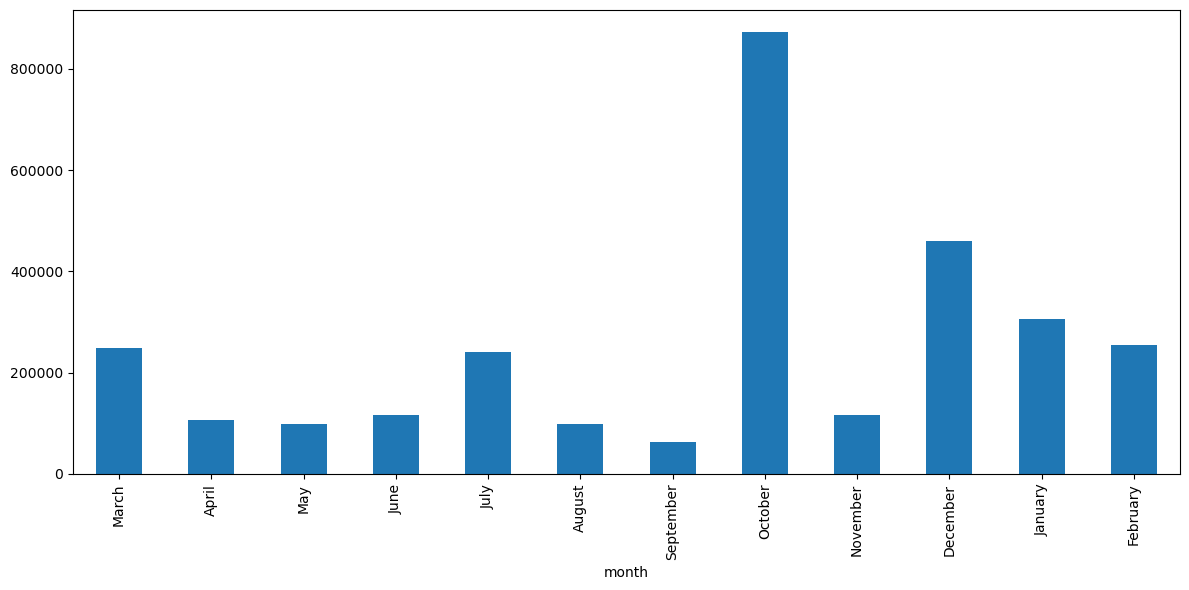

In [106]:
month_expenses.plot(kind='bar', figsize=(12,6))
plt.tight_layout()
plt.show()

In [111]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df['weekday'] = pd.Categorical(df['weekday'], categories=weekday_order, ordered=True)

category_spent = df.groupby('weekday', observed=True)['expense_abs'].sum()

In [112]:
print(category_spent)

weekday
Monday       567928.66
Tuesday      557725.22
Wednesday    329222.26
Thursday     270403.88
Friday       350865.78
Saturday     803176.87
Sunday       103844.64
Name: expense_abs, dtype: float64


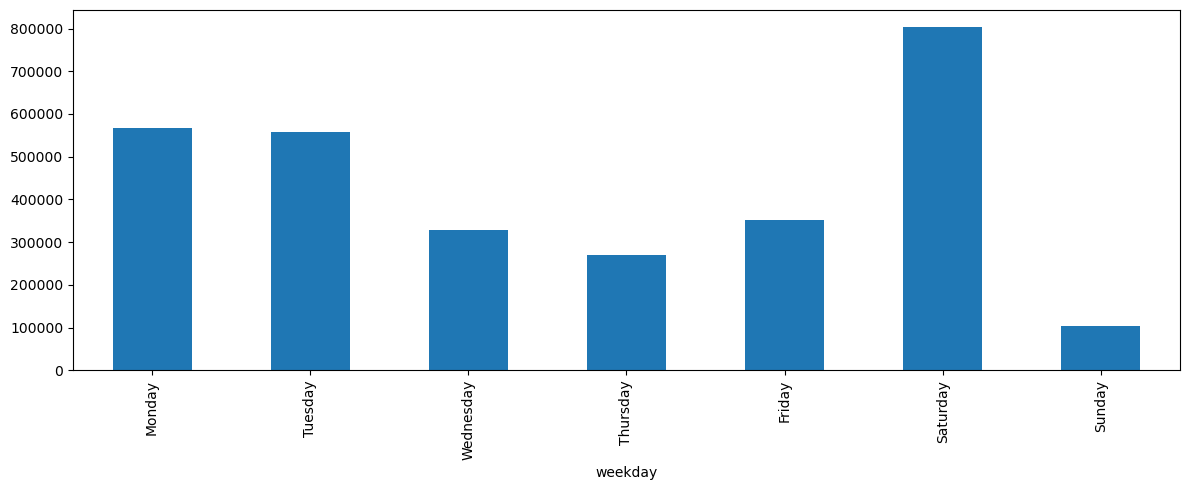

In [113]:
category_spent.plot(kind='bar', figsize=(12,5))
plt.tight_layout()
plt.show()